In [5]:
from pathlib import Path
import math
import pandas as pd
import folium
from PIL import Image
import numpy as np

SUMARE_RADAR_LAT = -22.955139
SUMARE_RADAR_LON = -43.248278
SUMARE_RADAR_RADIUS = 138900  # metros

RADAR_IMAGE_FILE = Path("/home/noemi/atmoseer/data/radar_sumare/2024/03/06/2024_03_06_00_13.png")
MAPPING_FILE = Path("/home/noemi/atmoseer/notebooks/sumare_radar/mapeamento_pixel_estacao.csv")

OUTPUT_DIR = Path("/home/noemi/atmoseer/notebooks/sumare_radar/outputs_tcc/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RADAR_TRANSPARENT_FILE = OUTPUT_DIR / "radar_sumare_transparente.png"
OUTPUT_HTML = OUTPUT_DIR / "overlay_radar_websirene.html"

In [ ]:
def make_white_transparent(input_path, output_path, threshold=245):
    img = Image.open(input_path).convert("RGBA")
    arr = np.array(img)

    r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
    white = (r > threshold) & (g > threshold) & (b > threshold)
    arr[white, 3] = 0

    Image.fromarray(arr).save(output_path)


make_white_transparent(RADAR_IMAGE_FILE, RADAR_TRANSPARENT_FILE)


radius_km = SUMARE_RADAR_RADIUS / 1000
deg_lat = radius_km / 111.32
deg_lon = radius_km / (111.32 * math.cos(math.radians(SUMARE_RADAR_LAT)))

lat_min = SUMARE_RADAR_LAT - deg_lat
lat_max = SUMARE_RADAR_LAT + deg_lat
lon_min = SUMARE_RADAR_LON - deg_lon
lon_max = SUMARE_RADAR_LON + deg_lon

bounds = [[lat_min, lon_min], [lat_max, lon_max]]


m = folium.Map(
    location=[SUMARE_RADAR_LAT, SUMARE_RADAR_LON],
    zoom_start=8,
    tiles="cartodbpositron",
)

folium.CircleMarker(
    location=[SUMARE_RADAR_LAT, SUMARE_RADAR_LON],
    radius=3,
    color="black",
    fill=True,
    fill_color="black",
    fill_opacity=1,
    popup="Radar do Sumaré",
).add_to(m)

folium.Circle(
    location=[SUMARE_RADAR_LAT, SUMARE_RADAR_LON],
    radius=SUMARE_RADAR_RADIUS,
    color="gray",
    fill=True,
    fill_opacity=0.08,
    weight=1,
    popup="Cobertura aproximada do Radar do Sumaré",
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=str(RADAR_TRANSPARENT_FILE),
    bounds=bounds,
    opacity=0.70,
    origin="upper",
    name="Radar do Sumaré",
).add_to(m)


#df = pd.read_csv(MAPPING_FILE)

#print(df.columns)

"""for _, row in df.iterrows():
    station_id = row["station_id"]
    lat = row["latitude"]
    lon = row["longitude"]

    nome = row["nome"] if "nome" in df.columns else f"Estação {station_id}"

    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=0.9,
        popup=f"{station_id} - {nome}",
    ).add_to(m)"""

folium.LayerControl().add_to(m)
m.save(OUTPUT_HTML)

print("Mapa salvo em:", OUTPUT_HTML)
print("Estações WebSirene plotadas:", len(df))

Index(['station_id', 'nome', 'latitude', 'longitude', 'pixel_i', 'pixel_j'], dtype='object')
Mapa salvo em: /home/noemi/atmoseer/notebooks/sumare_radar/outputs_tcc/overlay_radar_websirene.html
Estações WebSirene plotadas: 83



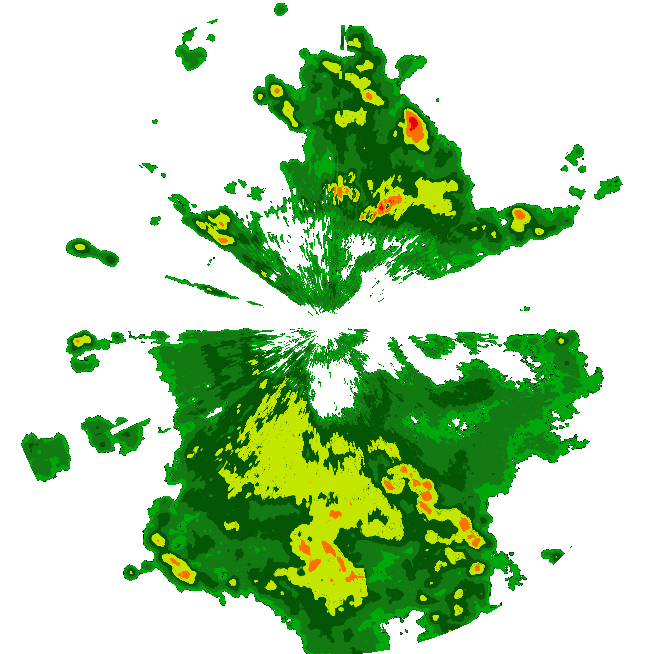

In [9]:
m